# **Persiapan Awal**

In [ ]:
# ==========================================
# 🔹 1. Setup (import & mount drive)
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# 🔹 2. Setup import
# ==========================================
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import pickle

In [ ]:
# =====================================================
# 🔹 3. Setup folder simpan model
# =====================================================
os.makedirs("/content/models_experiments", exist_ok=True)

drive_model_dir = "/content/drive/MyDrive/Tugas Akhir/1.Model/3.LSTM/Best_Model"
os.makedirs(drive_model_dir, exist_ok=True)

# **Persiapan Dataset**

In [ ]:
# ==========================================
# 🔹 4. Load dataset
# ==========================================
df = pd.read_csv('/content/drive/MyDrive/Tugas Akhir/Dataset/(3.1-LSTM) Preprocessing/Movie_Review_Processed_v4.csv')

sentences = df['sentence']
aspects = df['aspect']
labels = df['sentiment']  # 0=Negative, 1=Positive

# **Tokenizer & Padding**

In [ ]:
# ==========================================
# 🔹 5. Tokenizer & Padding
# ==========================================
MAX_WORDS = 10000
MAX_LEN_SENTENCE = 50
MAX_LEN_ASPECT = 4

tokenizer_sentence = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_aspect = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

tokenizer_sentence.fit_on_texts(sentences)
tokenizer_aspect.fit_on_texts(aspects)

seq_sentence = tokenizer_sentence.texts_to_sequences(sentences)
seq_aspect = tokenizer_aspect.texts_to_sequences(aspects)

pad_sentence = pad_sequences(seq_sentence, maxlen=MAX_LEN_SENTENCE, padding='post', truncating='post')
pad_aspect = pad_sequences(seq_aspect, maxlen=MAX_LEN_ASPECT, padding='post', truncating='post')

# **Pemisahan Data**

In [ ]:
# ==========================================
# 🔹 6. Split Data Train dan Test
# ==========================================
X_train_sent, X_test_sent, X_train_asp, X_test_asp, y_train, y_test = train_test_split(
    pad_sentence, pad_aspect, labels, test_size=0.2, random_state=42, stratify=labels
)

# **Pendefinisian Parameter**

In [ ]:
# ==========================================
# 🔹 7. Definisi eksperimen parameter
# ==========================================
param_grid = {
    "embedding_dim": [64, 128],
    "lstm_units_sentence": [64, 128],
    "lstm_units_aspect": [32, 64],
    "batch_size": [32, 64],
    "learning_rate": [0.001, 0.0005]
}

results = []
history_dict = {}
best_overall_acc = 0
best_overall_model = None
best_overall_name = ""

# **Eksperimen Parameter**

In [ ]:
# ==========================================
# 🔹 8. Loop eksperimen
# ==========================================
all_f1_curves = {}       # Simpan F1 per epoch semua model
all_histories = {}       # Simpan history accuracy & loss semua model

for emb_dim in param_grid["embedding_dim"]:
    for lstm_sent in param_grid["lstm_units_sentence"]:
        for lstm_asp in param_grid["lstm_units_aspect"]:
            for bs in param_grid["batch_size"]:
                for lr in param_grid["learning_rate"]:

                    param_name = f"emb{emb_dim}_lstmS{lstm_sent}_lstmA{lstm_asp}_bs{bs}_lr{lr}"
                    print(f"\n🚀 Training model dengan {param_name}")

                    # Reset session agar memory tidak penuh
                    tf.keras.backend.clear_session()

                    # Model
                    input_sentence = Input(shape=(MAX_LEN_SENTENCE,), name='sentence_input')
                    embedding_sentence = Embedding(input_dim=MAX_WORDS, output_dim=emb_dim)(input_sentence)
                    lstm_sentence = LSTM(lstm_sent)(embedding_sentence)

                    input_aspect = Input(shape=(MAX_LEN_ASPECT,), name='aspect_input')
                    embedding_aspect = Embedding(input_dim=MAX_WORDS, output_dim=emb_dim)(input_aspect)
                    lstm_aspect = LSTM(lstm_asp)(embedding_aspect)

                    merged = Concatenate()([lstm_sentence, lstm_aspect])
                    dense = Dense(64, activation='relu')(merged)
                    drop = Dropout(0.3)(dense)
                    output = Dense(1, activation='sigmoid')(drop)

                    model = Model(inputs=[input_sentence, input_aspect], outputs=output)
                    model.compile(
                        loss='binary_crossentropy',
                        optimizer=Adam(learning_rate=lr),
                        metrics=['accuracy']
                    )

                    # Callback
                    checkpoint_path = f"/content/models_experiments/{param_name}.h5"
                    checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_loss", mode="min",
                                                 save_best_only=True, verbose=0)
                    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

                    # Train
                    history = model.fit(
                        [X_train_sent, X_train_asp], y_train,
                        validation_data=([X_test_sent, X_test_asp], y_test),
                        epochs=30,
                        batch_size=bs,
                        callbacks=[early_stop, checkpoint],
                        verbose=0
                    )

                    # 🔹 Simpan history untuk plotting nanti
                    all_histories[param_name] = history.history

                     # 🔹 Hitung F1 tiap epoch
                    f1_scores_epoch = []
                    for epoch in range(len(history.history['loss'])):
                        y_pred_epoch = (model.predict([X_test_sent, X_test_asp]) > 0.5).astype(int).reshape(-1)
                        f1_epoch = f1_score(y_test, y_pred_epoch)
                        f1_scores_epoch.append(f1_epoch)

                    all_f1_curves[param_name] = f1_scores_epoch

                    # Evaluasi best model
                    best_model = tf.keras.models.load_model(checkpoint_path)
                    y_pred = (best_model.predict([X_test_sent, X_test_asp]) > 0.5).astype(int).reshape(-1)

                    acc = accuracy_score(y_test, y_pred)

                    # 🔹 Dapatkan classification report lengkap
                    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

                    print(f"✅ {param_name} | Acc: {acc:.4f}, F1_macro: {report['macro avg']['f1-score']:.4f}")

                    # 🔹 Simpan hasil lengkap
                    results.append({
                        "embedding_dim": emb_dim,
                        "lstm_units_sentence": lstm_sent,
                        "lstm_units_aspect": lstm_asp,
                        "batch_size": bs,
                        "learning_rate": lr,
                        "accuracy": acc,
                        # Macro & Weighted average
                        "precision_macro": report["macro avg"]["precision"],
                        "recall_macro": report["macro avg"]["recall"],
                        "f1_macro": report["macro avg"]["f1-score"],
                        "precision_weighted": report["weighted avg"]["precision"],
                        "recall_weighted": report["weighted avg"]["recall"],
                        "f1_weighted": report["weighted avg"]["f1-score"],
                        # Per-class (0 = negative, 1 = positive)
                        "precision_neg": report["0"]["precision"],
                        "recall_neg": report["0"]["recall"],
                        "f1_neg": report["0"]["f1-score"],
                        "precision_pos": report["1"]["precision"],
                        "recall_pos": report["1"]["recall"],
                        "f1_pos": report["1"]["f1-score"],
                        "model_path": checkpoint_path
                    })

                    # 🔹 Simpan model terbaik secara keseluruhan (misalnya pakai F1-macro)
                    if report["macro avg"]["f1-score"] > best_overall_acc:
                        best_overall_acc = report["macro avg"]["f1-score"]
                        best_overall_model = best_model
                        best_overall_name = param_name


🚀 Training model dengan emb64_lstmS64_lstmA32_bs32_lr0.001


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
✅ emb64_lstmS64_lstmA32_bs32_lr0.001 | Acc: 0.7180, F1_macro: 0.7174

🚀 Training model dengan emb64_lstmS64_lstmA32_bs32_lr0.0005


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
✅ emb64_lstmS64_lstmA32_bs32_lr0.0005 | Acc: 0.7967, F1_macro: 0.7965

🚀 Training model dengan emb64_lstmS64_lstmA32_bs64_lr0.001


...

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
✅ emb128_lstmS128_lstmA64_bs32_lr0.0005 | Acc: 0.8044, F1_macro: 0.8036

🚀 Training model dengan emb128_lstmS128_lstmA64_bs64_lr0.001


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
✅ emb128_lstmS128_lstmA64_bs64_lr0.001 | Acc: 0.7934, F1_macro: 0.7915

🚀 Training model dengan emb128_lstmS128_lstmA64_bs64_lr0.0005


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
✅ emb128_lstmS128_lstmA64_bs64_lr0.0005 | Acc: 0.8087, F1_macro: 0.8085


# **Simpan Hasil Eksperimen**

In [ ]:
# ==========================================
# 🔹 9. Lihat summary model terbaiknya
# ==========================================
best_overall_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sentence_input      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aspect_input        │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 64)    │    640,000 │ sentence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 64)     │    640,000 │ aspect_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     33,024 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,354,371 (5.17 MB)

 Trainable params: 1,354,369 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# ==========================================
# 🔹 10. Lihat parameter terbaik
# ==========================================
# Ambil parameter terbaik dari nama model
best_params = {}
name_parts = best_overall_name.split("_")

for part in name_parts:
    if part.startswith("emb"):
        best_params["embedding_dim"] = int(part.replace("emb", ""))
    elif part.startswith("lstmS"):
        best_params["lstm_units_sentence"] = int(part.replace("lstmS", ""))
    elif part.startswith("lstmA"):
        best_params["lstm_units_aspect"] = int(part.replace("lstmA", ""))
    elif part.startswith("bs"):
        best_params["batch_size"] = int(part.replace("bs", ""))
    elif part.startswith("lr"):
        best_params["learning_rate"] = float(part.replace("lr", ""))

print("🔹 Konfigurasi terbaik:")
for k, v in best_params.items():
    print(f"{k}: {v}")


🔹 Konfigurasi terbaik:
embedding_dim: 64
lstm_units_sentence: 64
lstm_units_aspect: 64
batch_size: 64
learning_rate: 0.001


In [ ]:
# ==========================================
# 🔹 11. Simpan hasil eksperimen ke CSV (langsung ke Drive)
# ==========================================
results_df = pd.DataFrame(results)
csv_drive_path = os.path.join(drive_model_dir, "results_lstm_experiments.csv")
results_df.to_csv(csv_drive_path, index=False)

print(f"\n📊 Semua hasil eksperimen tersimpan di {csv_drive_path}")


📊 Semua hasil eksperimen tersimpan di /content/drive/MyDrive/Tugas Akhir/1.Model/3.LSTM/Best_Model/results_lstm_experiments.csv


In [ ]:
# ==========================================
# 🔹 12. Simpan model terbaik (ke Drive, lengkap dgn tokenizer)
# ==========================================
if best_overall_model is not None:
    best_path = os.path.join(drive_model_dir, f"best_model_{best_overall_name}.h5")
    best_overall_model.save(best_path)

    # Simpan tokenizer
    with open(os.path.join(drive_model_dir, "tokenizer_sentence.pkl"), "wb") as f:
        pickle.dump(tokenizer_sentence, f)

    with open(os.path.join(drive_model_dir, "tokenizer_aspect.pkl"), "wb") as f:
        pickle.dump(tokenizer_aspect, f)

    print(f"🏆 Model terbaik ({best_overall_name}) disimpan ke {best_path}")

🏆 Model terbaik (emb64_lstmS64_lstmA64_bs64_lr0.001) disimpan ke /content/drive/MyDrive/Tugas Akhir/1.Model/3.LSTM/Best_Model/best_model_emb64_lstmS64_lstmA64_bs64_lr0.001.h5


# **Experiment Graph**

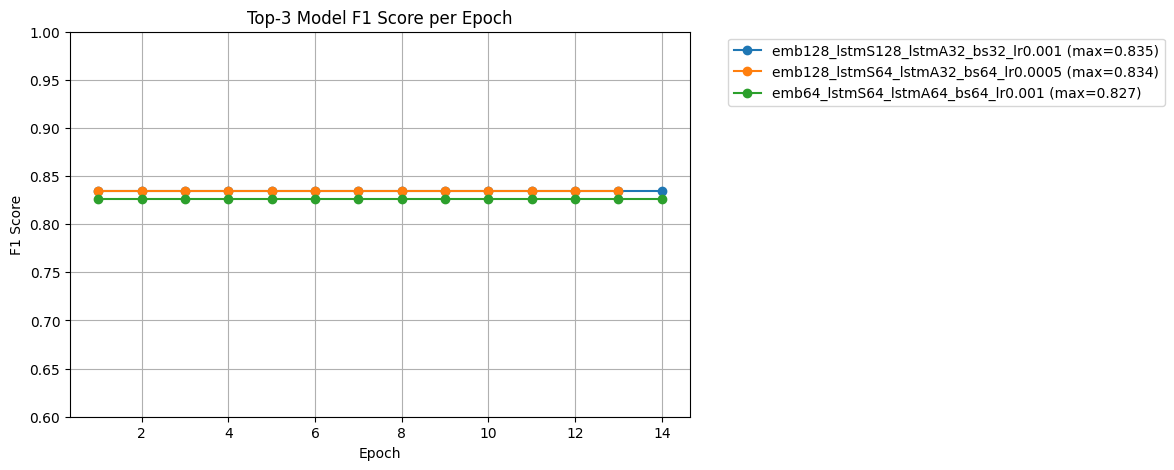

In [ ]:
# ==========================================
# 🔹 13. Grafik Top-3 F1 per Epoch (Lebih Jelas)
# ==========================================
# Urutkan model berdasarkan nilai F1 tertinggi
top_models = sorted(all_f1_curves.items(), key=lambda x: max(x[1]), reverse=True)[:3]

plt.figure(figsize=(8,5))
for name, f1_values in top_models:
    plt.plot(range(1, len(f1_values)+1), f1_values, marker="o", label=f"{name} (max={max(f1_values):.3f})")

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Top-3 Model F1 Score per Epoch")
plt.ylim(0.6, 1.0)  # 🔹 Zoom in biar variasi kelihatan
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

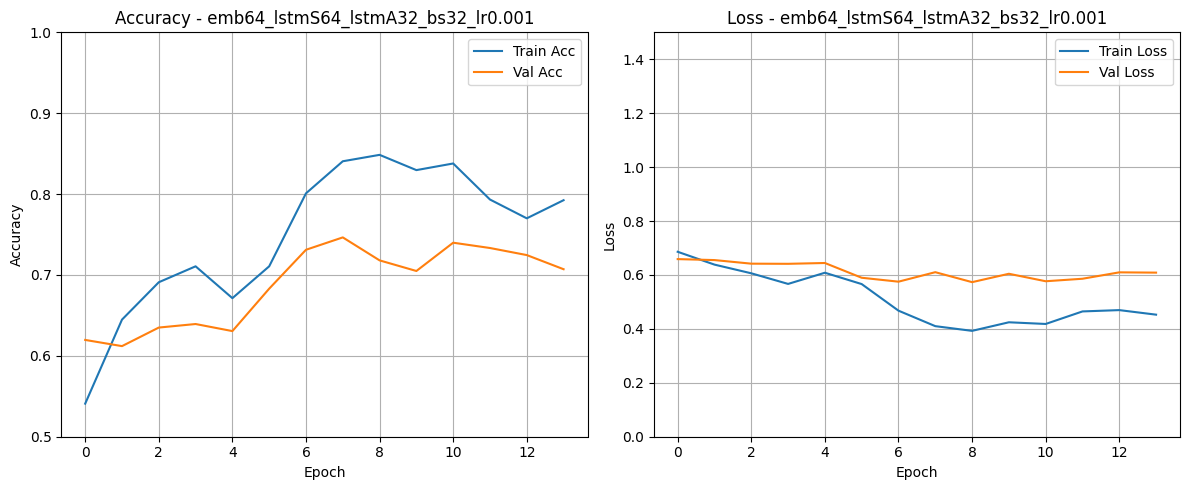

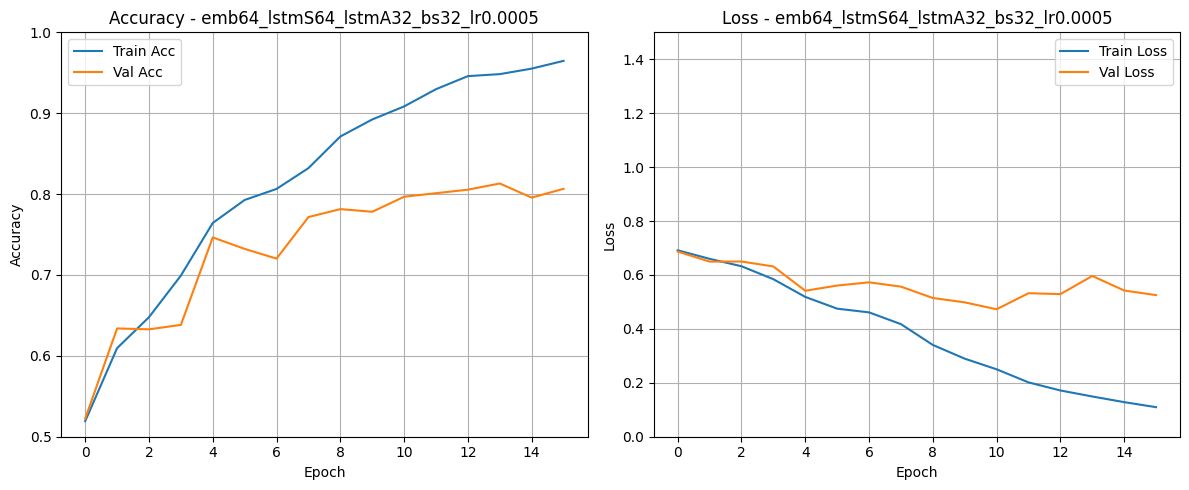

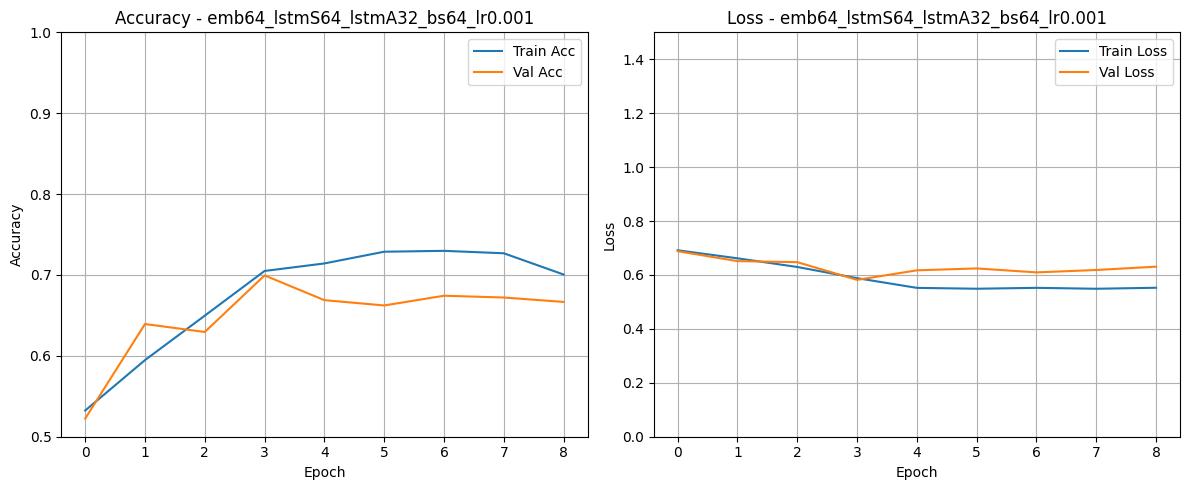

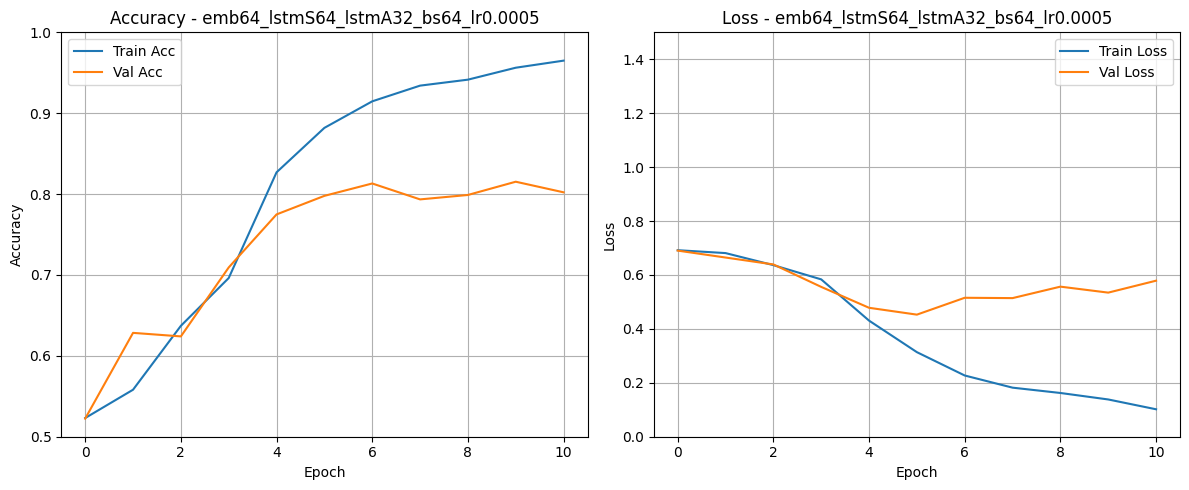

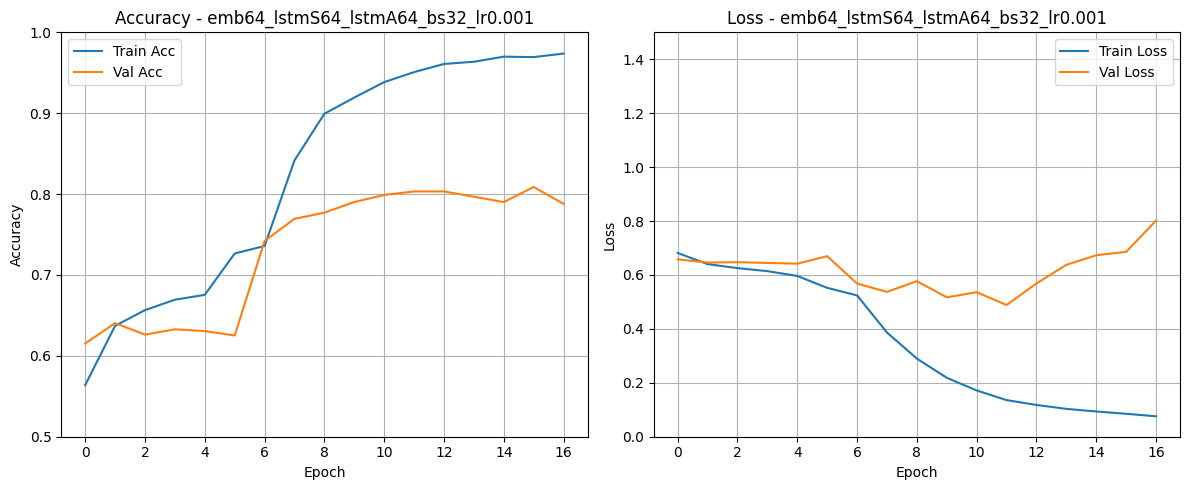

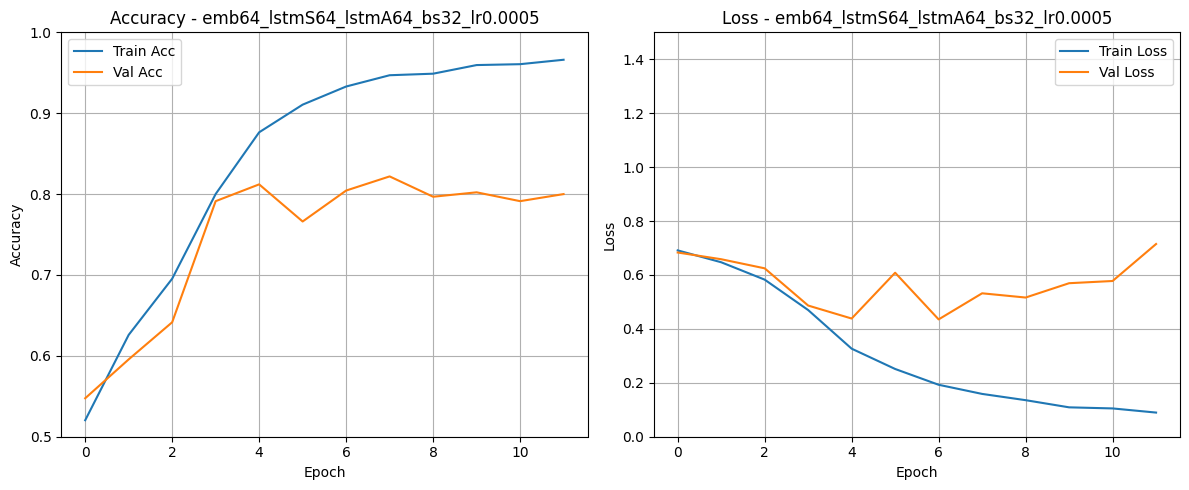

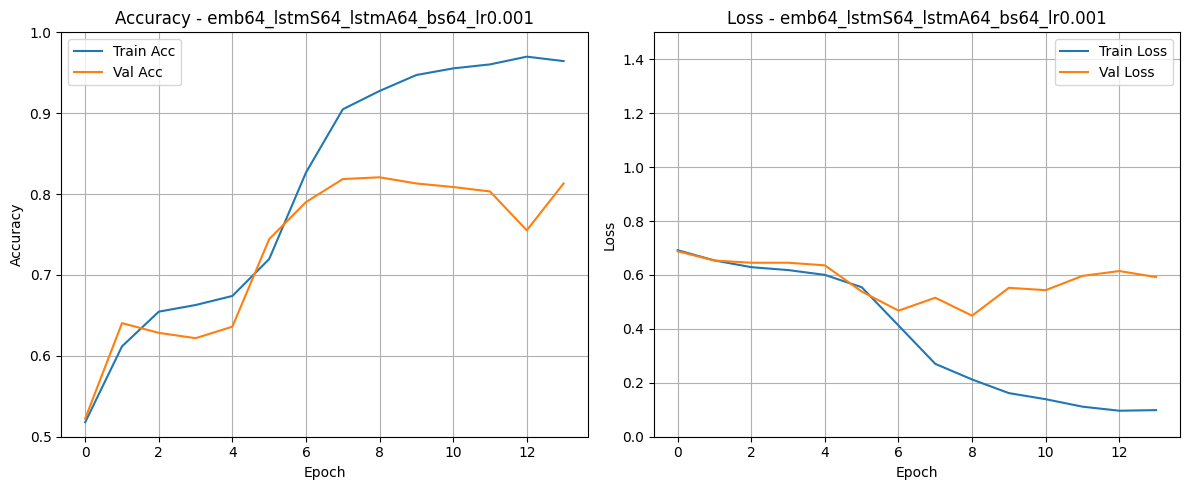

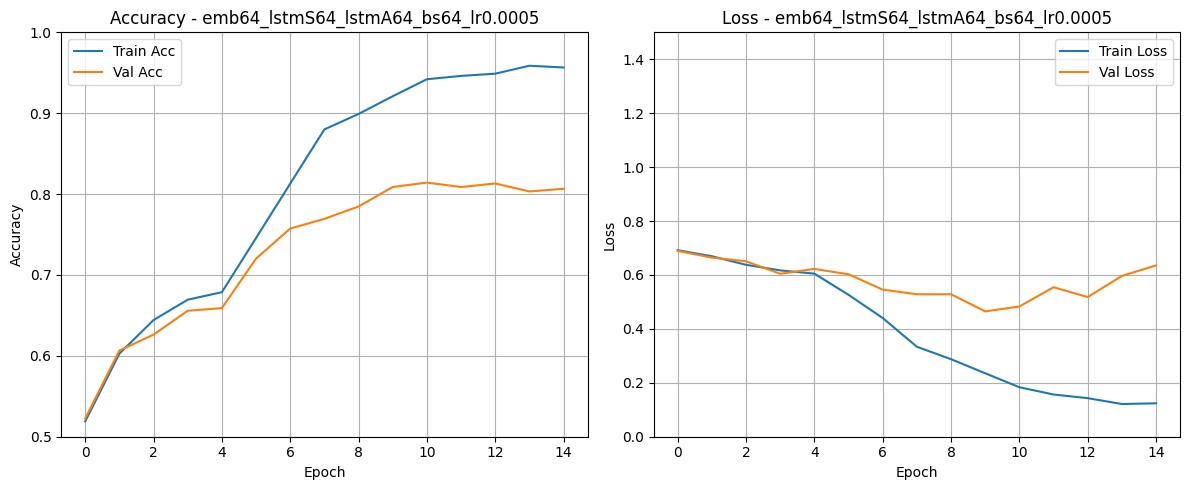

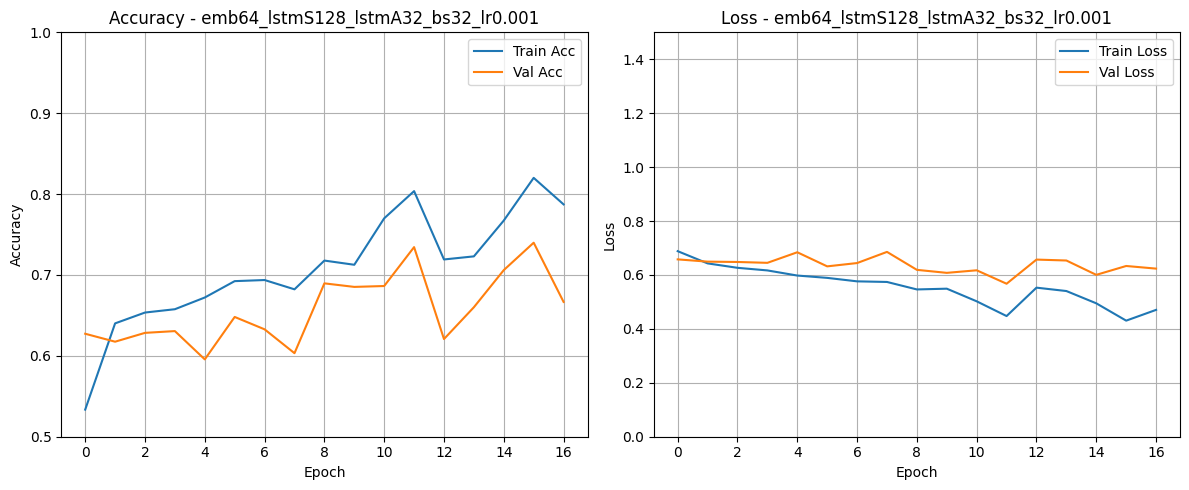

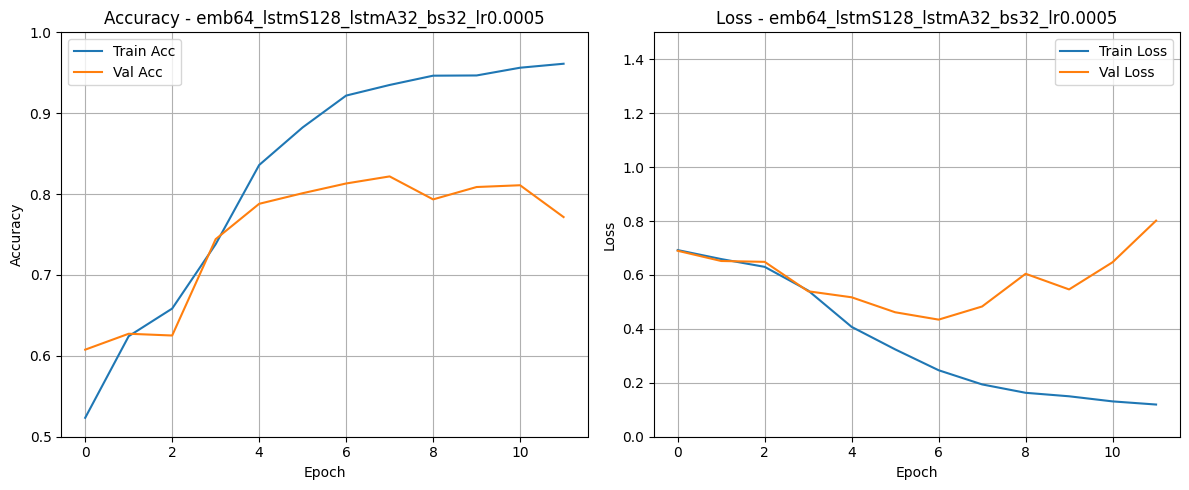

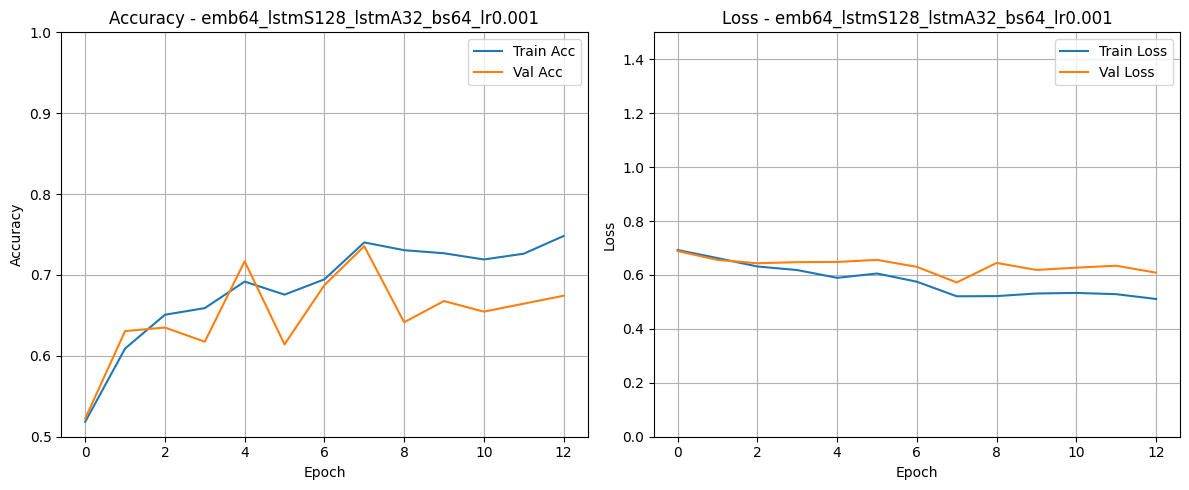

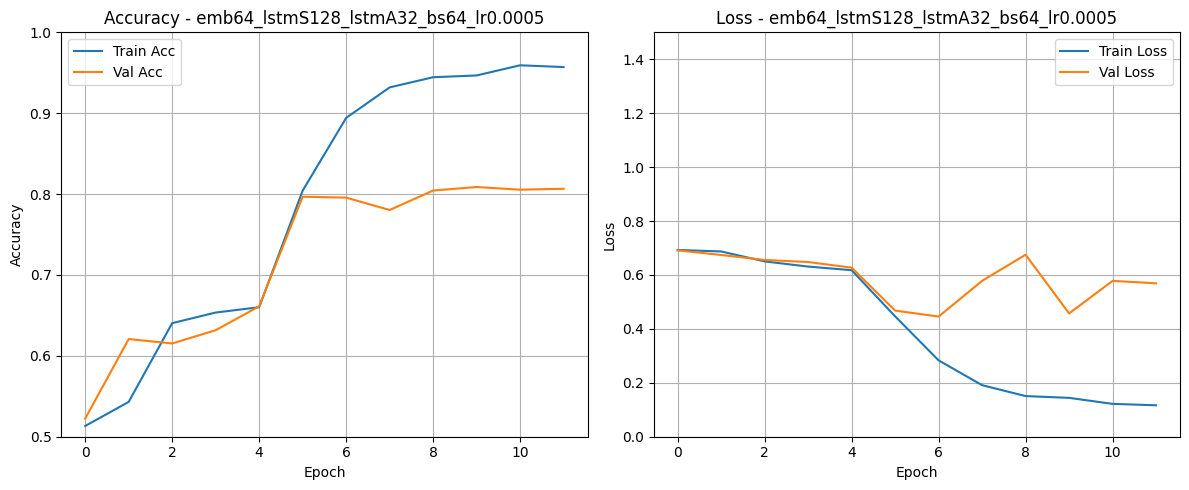

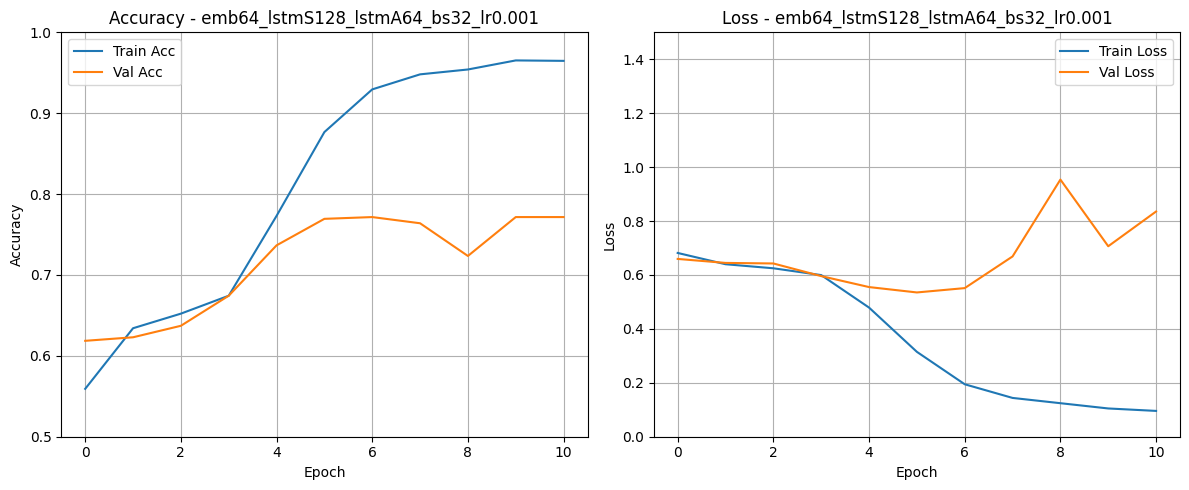

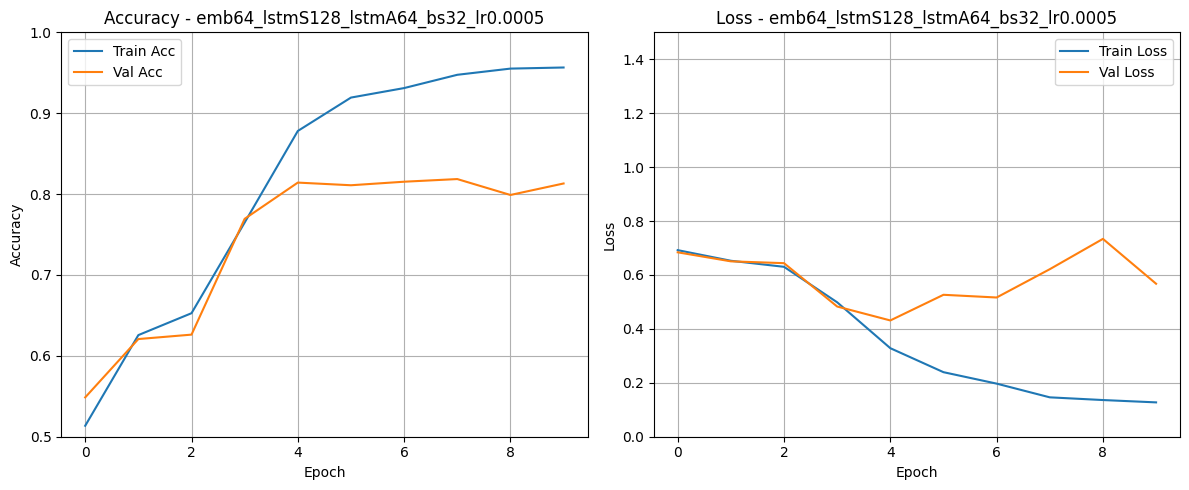

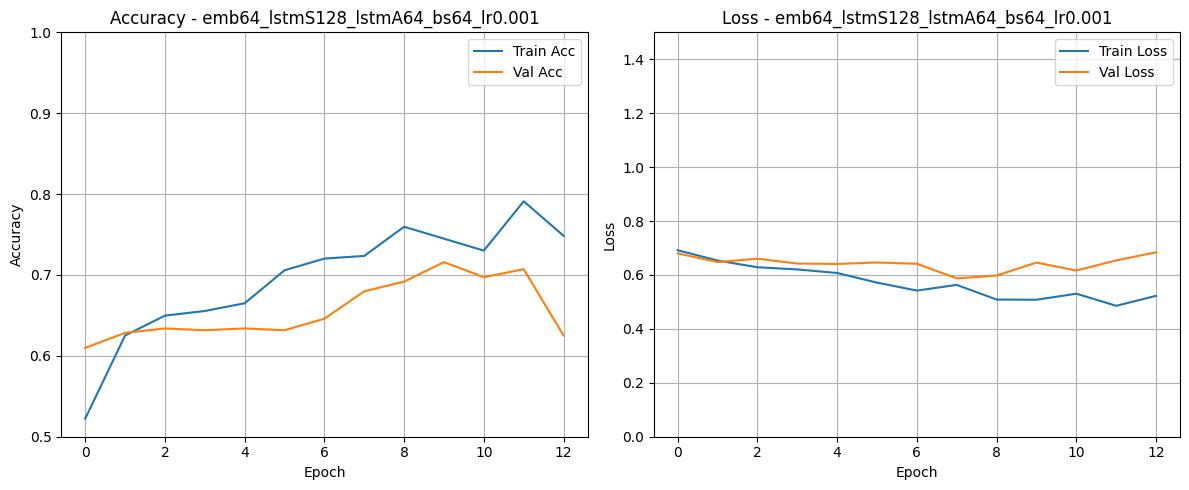

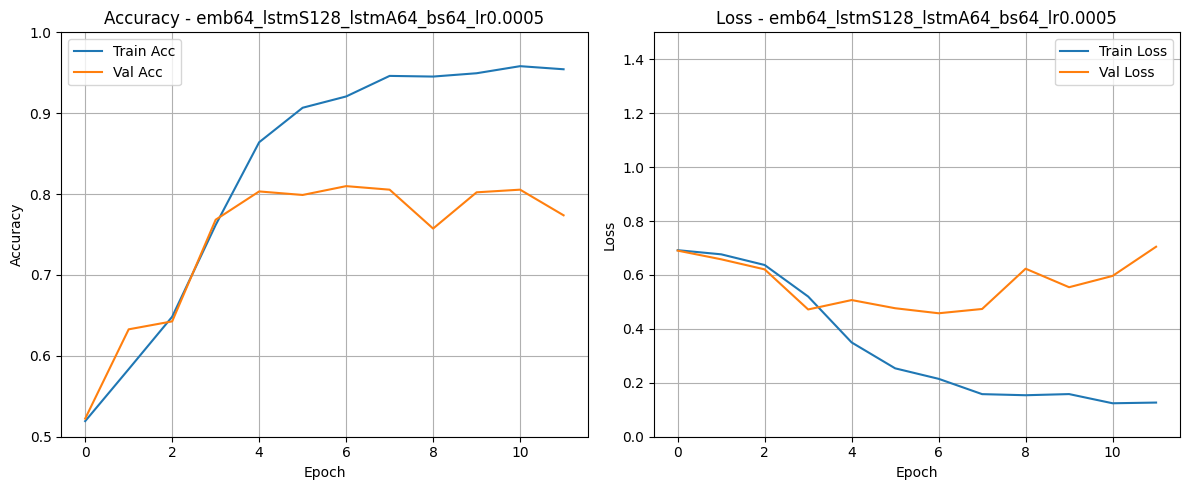

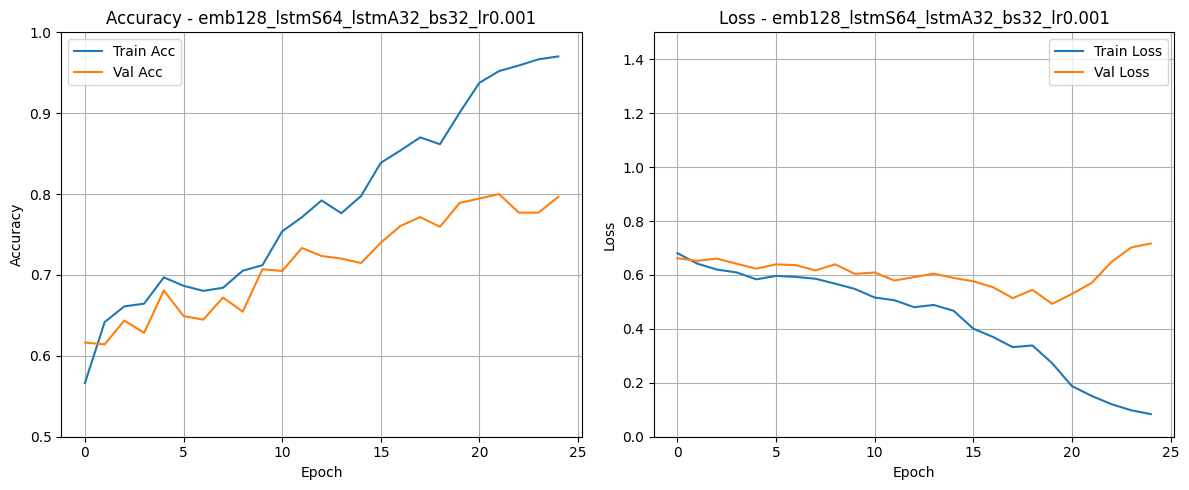

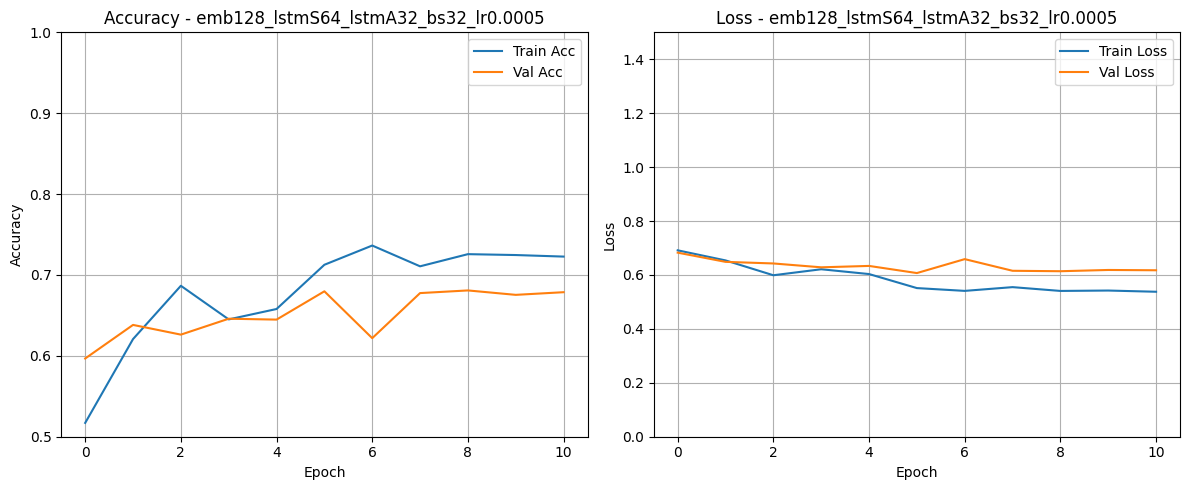

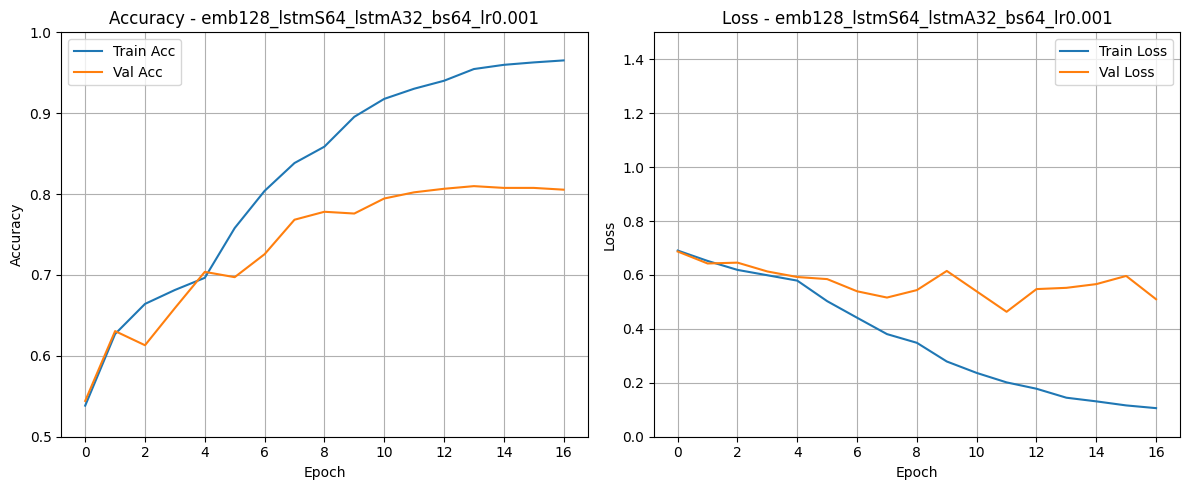

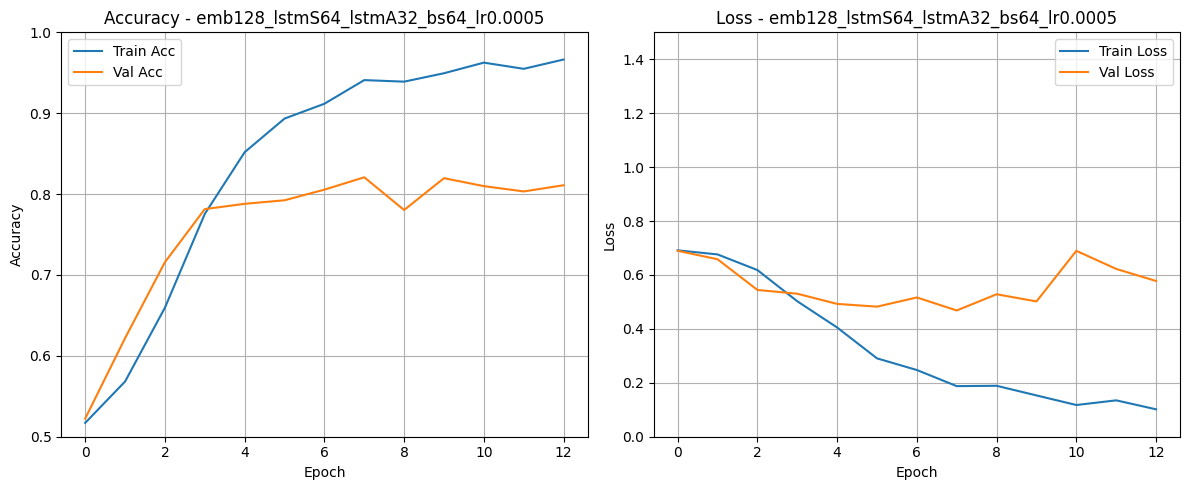

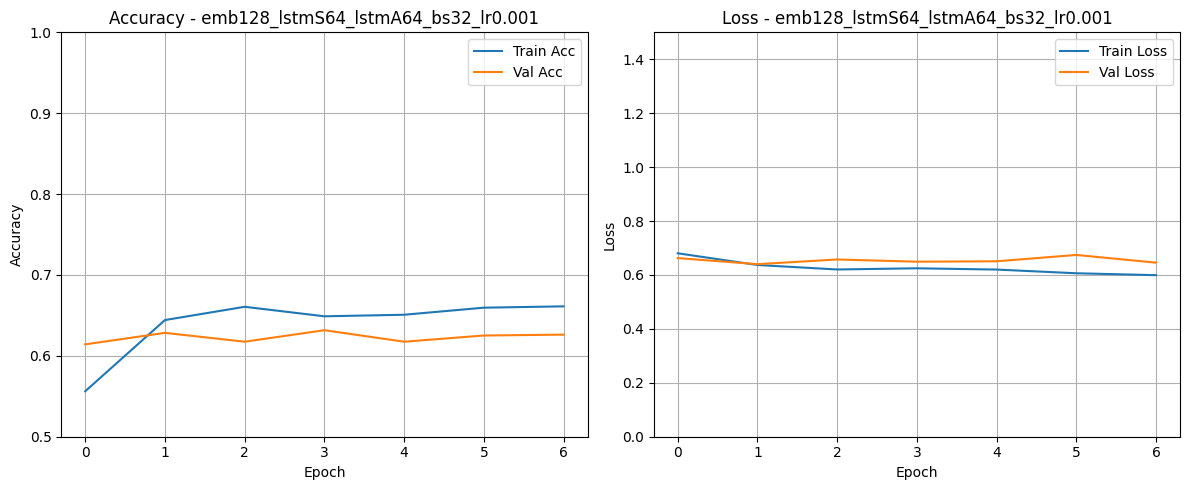

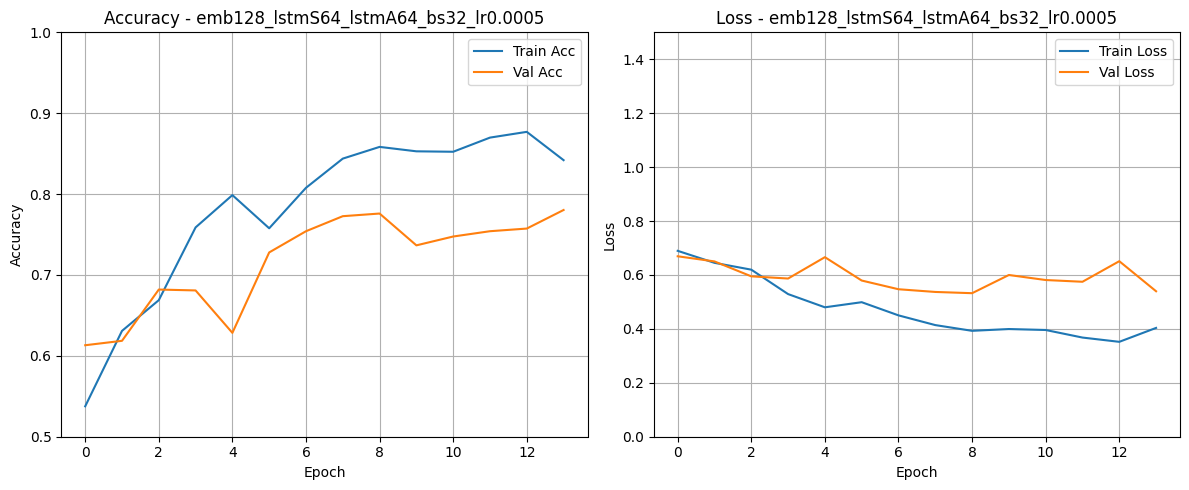

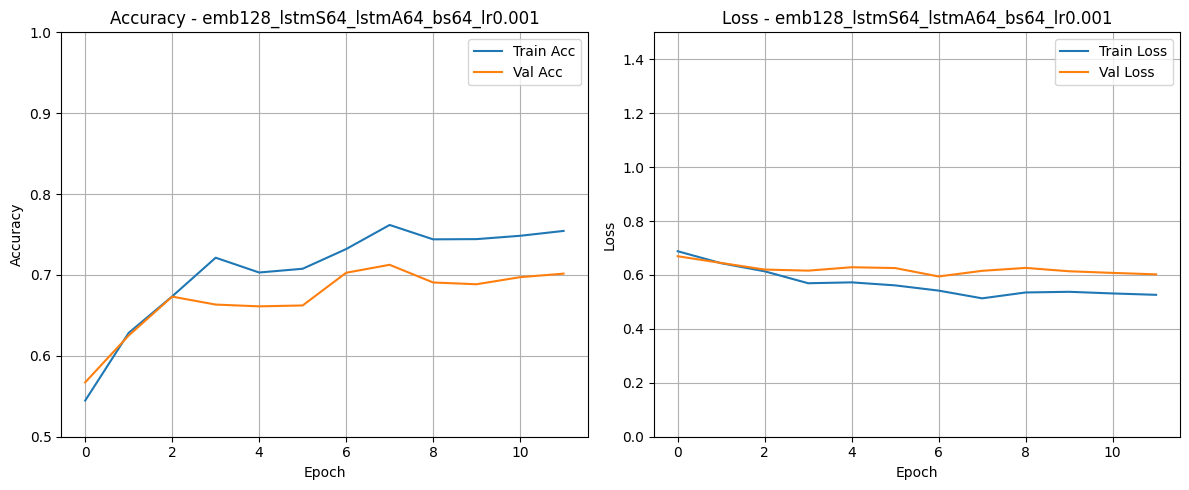

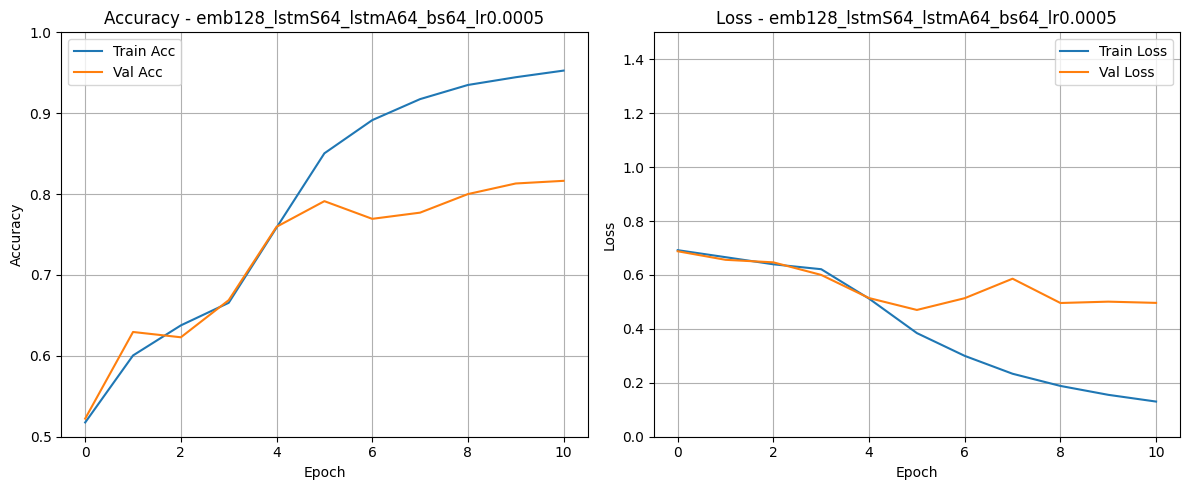

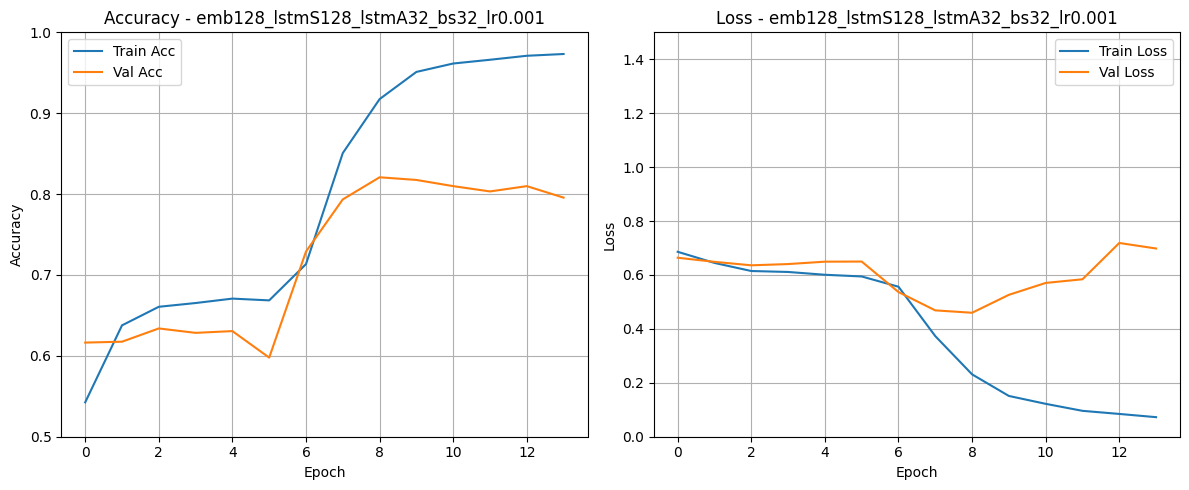

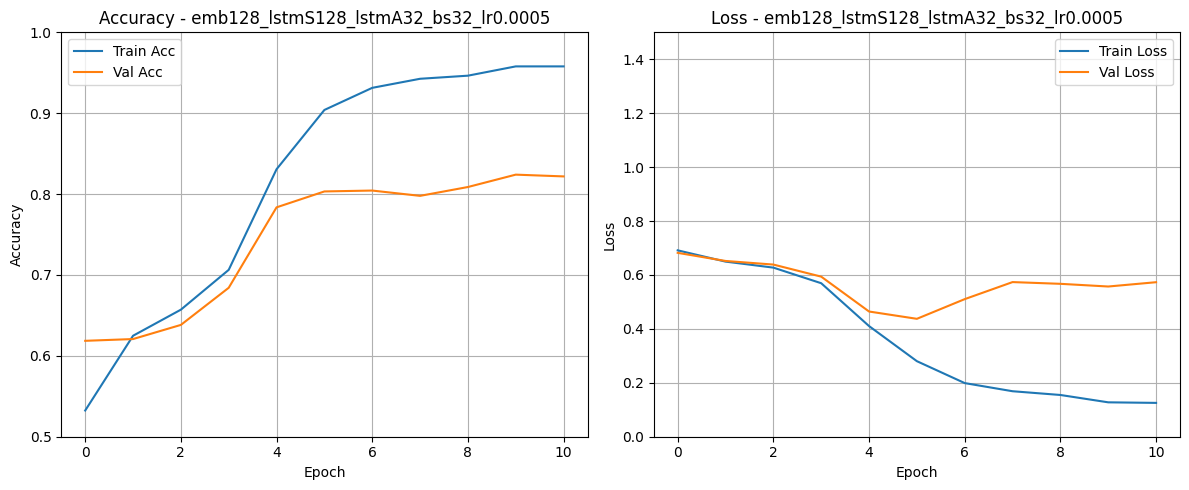

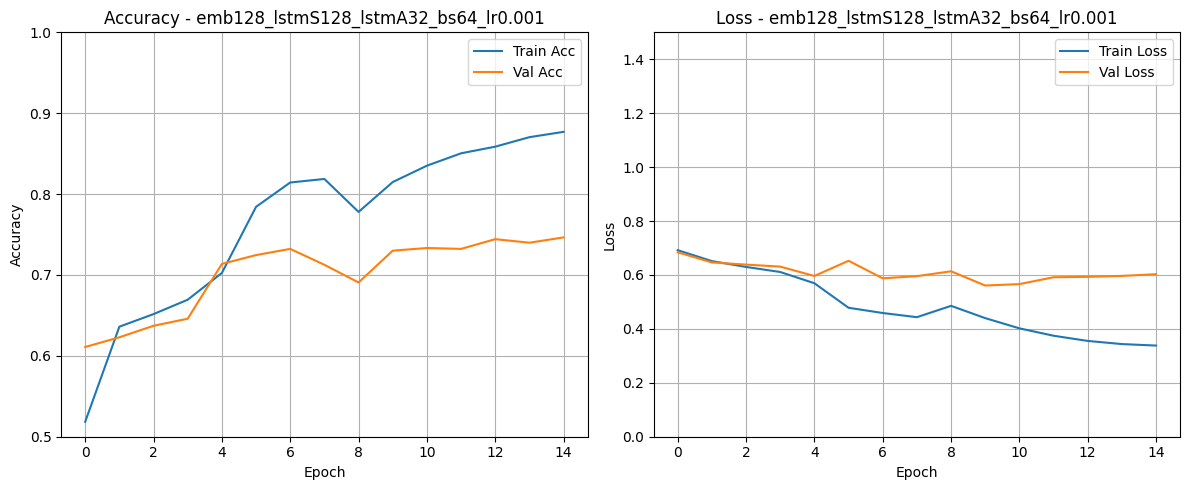

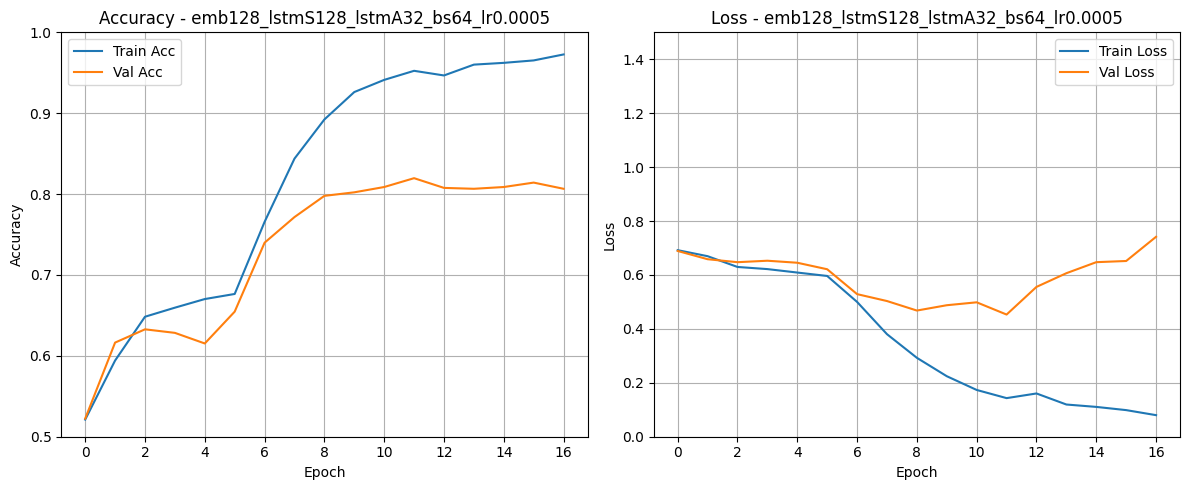

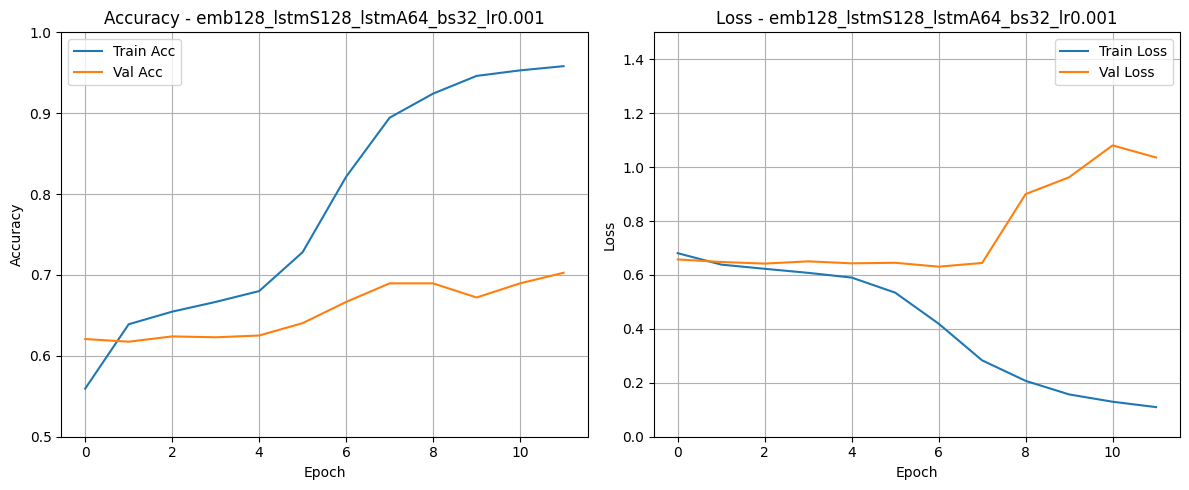

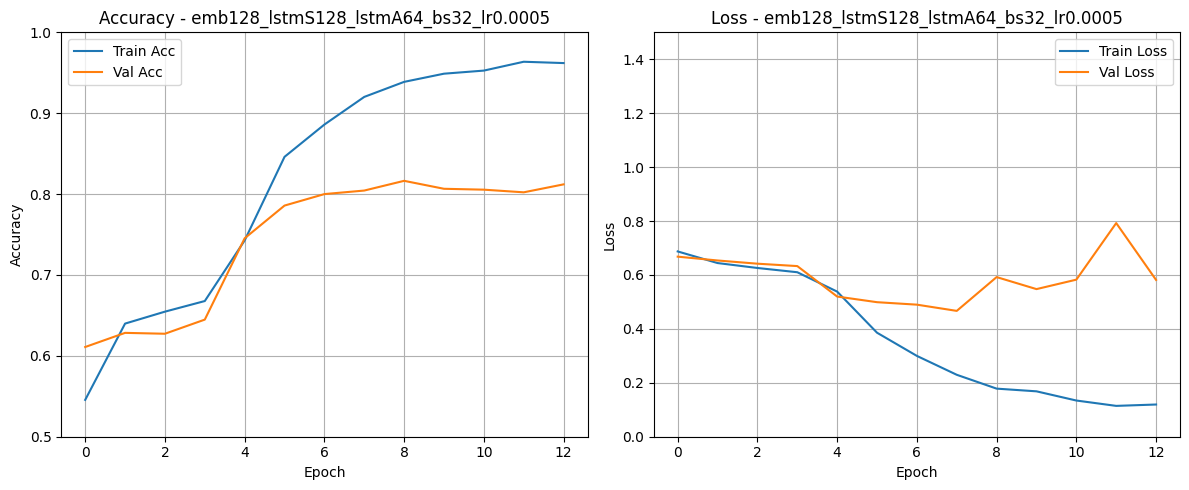

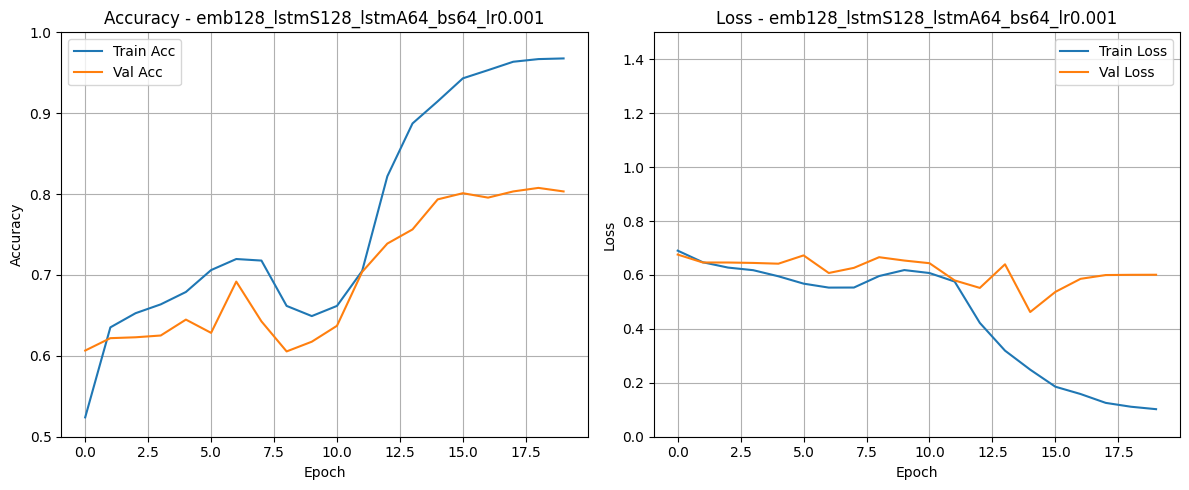

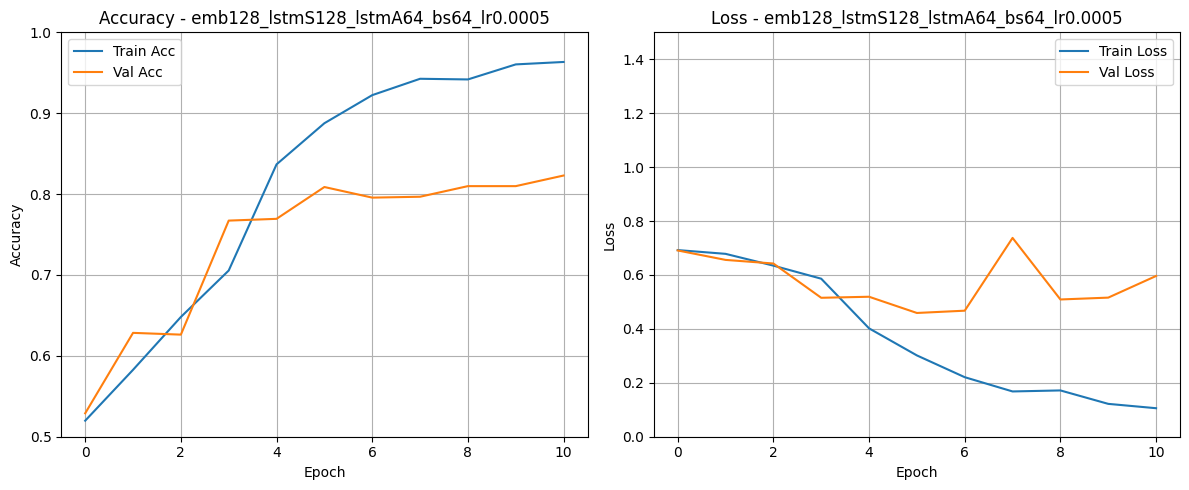

In [ ]:
# ==========================================
# 🔹 14. Grafik Terpisah untuk Semua Model
# ==========================================
for name, hist in all_histories.items():
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(hist['accuracy'], label='Train Acc')
    plt.plot(hist['val_accuracy'], label='Val Acc')
    plt.title(f'Accuracy - {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0.5, 1.0)   # 🔹 zoom in biar lebih kelihatan
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title(f'Loss - {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim(0, 1.5)     # 🔹 biar skala konsisten
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

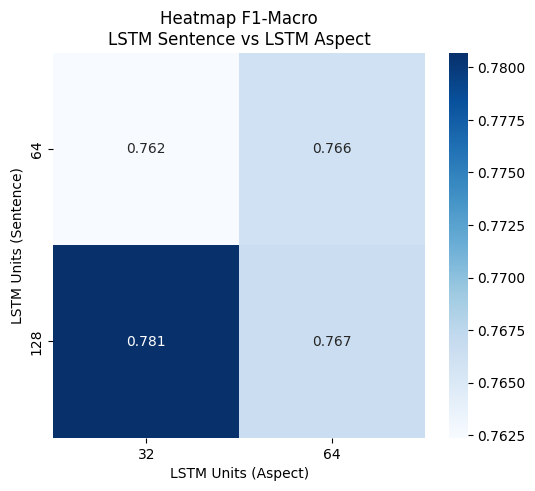

/tmp/ipython-input-1987129794.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="embedding_dim", y="f1_macro", ci=None)


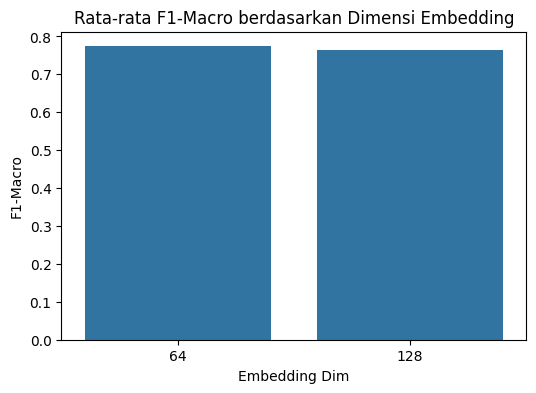

/tmp/ipython-input-1987129794.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="batch_size", y="f1_macro", ci=None)


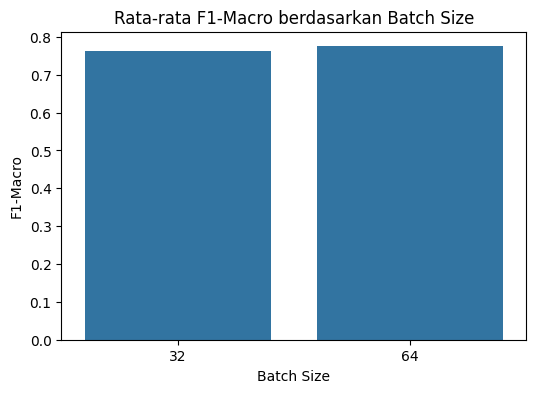

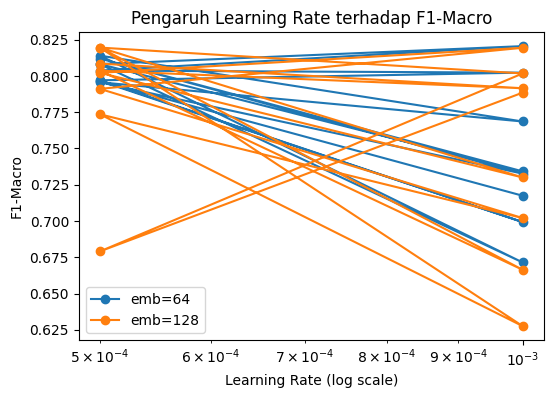

In [ ]:
# ==========================================
# 🔹 15. Grafik Perbandingan Antar Parameter
# ==========================================
# ----- 15.1 Grafik LSTM Sentence vs LSTM Aspect
df = pd.DataFrame(results)

pivot = df.pivot_table(
    index="lstm_units_sentence",
    columns="lstm_units_aspect",
    values="f1_macro",
    aggfunc="mean"
)

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues")
plt.title("Heatmap F1-Macro\nLSTM Sentence vs LSTM Aspect")
plt.ylabel("LSTM Units (Sentence)")
plt.xlabel("LSTM Units (Aspect)")
plt.show()

# ----- 15.2 Grafik Perbandingan Embedding Dim
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="embedding_dim", y="f1_macro", ci=None)
plt.title("Rata-rata F1-Macro berdasarkan Dimensi Embedding")
plt.xlabel("Embedding Dim")
plt.ylabel("F1-Macro")
plt.show()

# ----- 15.3 Grafik Perbandingan Batch Size
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="batch_size", y="f1_macro", ci=None)
plt.title("Rata-rata F1-Macro berdasarkan Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("F1-Macro")
plt.show()

# ----- 15.4 Grafik Perbandingan Learning Rate vs F1
plt.figure(figsize=(6,4))
for emb in df["embedding_dim"].unique():
    subset = df[df["embedding_dim"] == emb]
    plt.plot(subset["learning_rate"], subset["f1_macro"], marker="o", label=f"emb={emb}")

plt.xscale("log")
plt.title("Pengaruh Learning Rate terhadap F1-Macro")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("F1-Macro")
plt.legend()
plt.show()

/tmp/ipython-input-825982649.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="embedding_dim", y="f1_macro", data=results_df, ci=None)


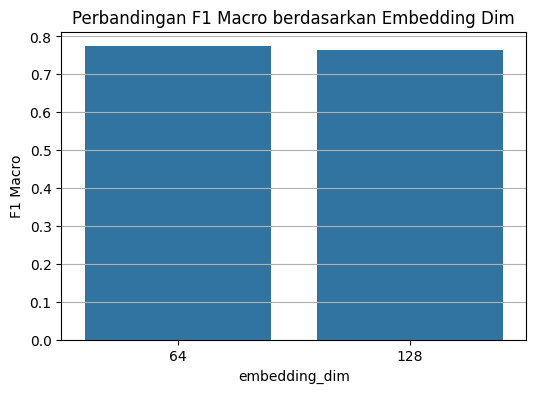

/tmp/ipython-input-825982649.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="learning_rate", y="f1_macro", data=results_df, ci=None)


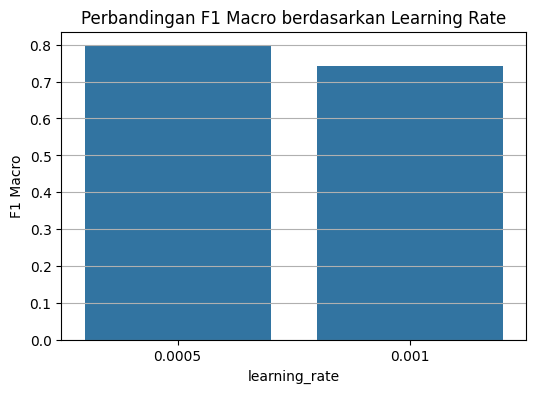

/tmp/ipython-input-825982649.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="lstm_units_sentence", y="f1_macro", data=results_df, ci=None)


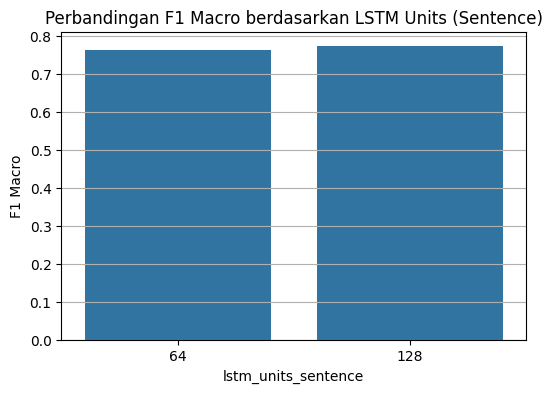

/tmp/ipython-input-825982649.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="lstm_units_aspect", y="f1_macro", data=results_df, ci=None)


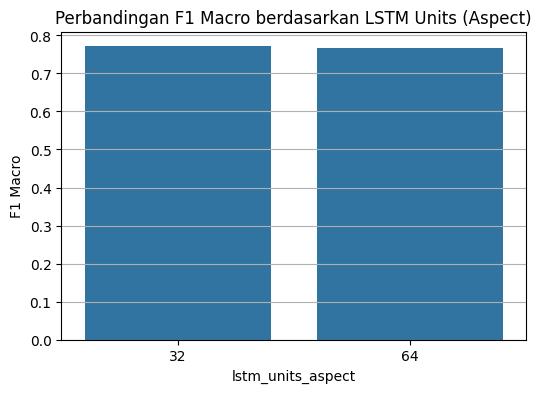

/tmp/ipython-input-825982649.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="batch_size", y="f1_macro", data=results_df, ci=None)


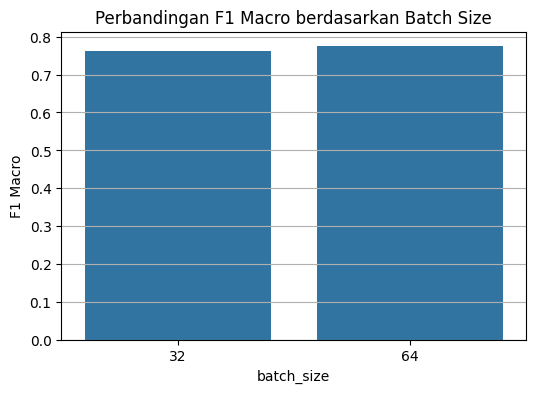

/tmp/ipython-input-825982649.py:51: FutureWarning: The provided callable <function mean at 0x7e06f412c9a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = results_df.pivot_table(


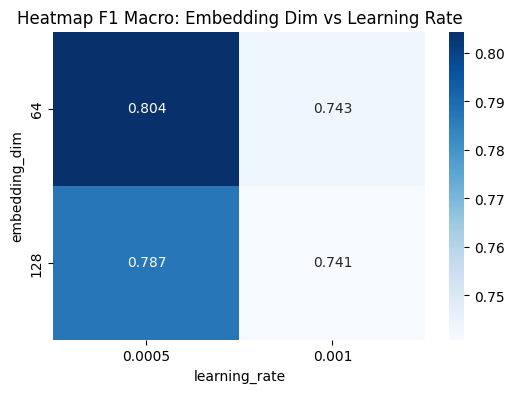

In [ ]:
# ==========================================
# 🔹 16. Grafik Perbandingan Antar Parameter
# ==========================================

import seaborn as sns

# Pastikan dataframe hasil ada
results_df = pd.DataFrame(results)

# 1. Perbandingan embedding_dim
plt.figure(figsize=(6,4))
sns.barplot(x="embedding_dim", y="f1_macro", data=results_df, ci=None)
plt.title("Perbandingan F1 Macro berdasarkan Embedding Dim")
plt.ylabel("F1 Macro")
plt.grid(True, axis='y')
plt.show()

# 2. Perbandingan learning_rate
plt.figure(figsize=(6,4))
sns.barplot(x="learning_rate", y="f1_macro", data=results_df, ci=None)
plt.title("Perbandingan F1 Macro berdasarkan Learning Rate")
plt.ylabel("F1 Macro")
plt.grid(True, axis='y')
plt.show()

# 3. Perbandingan lstm_units_sentence
plt.figure(figsize=(6,4))
sns.barplot(x="lstm_units_sentence", y="f1_macro", data=results_df, ci=None)
plt.title("Perbandingan F1 Macro berdasarkan LSTM Units (Sentence)")
plt.ylabel("F1 Macro")
plt.grid(True, axis='y')
plt.show()

# 4. Perbandingan lstm_units_aspect
plt.figure(figsize=(6,4))
sns.barplot(x="lstm_units_aspect", y="f1_macro", data=results_df, ci=None)
plt.title("Perbandingan F1 Macro berdasarkan LSTM Units (Aspect)")
plt.ylabel("F1 Macro")
plt.grid(True, axis='y')
plt.show()

# 5. Perbandingan batch_size
plt.figure(figsize=(6,4))
sns.barplot(x="batch_size", y="f1_macro", data=results_df, ci=None)
plt.title("Perbandingan F1 Macro berdasarkan Batch Size")
plt.ylabel("F1 Macro")
plt.grid(True, axis='y')
plt.show()

# 6. Heatmap kombinasi parameter (contoh untuk embedding_dim vs learning_rate)
pivot_table = results_df.pivot_table(
    values="f1_macro",
    index="embedding_dim",
    columns="learning_rate",
    aggfunc=np.mean
)

plt.figure(figsize=(6,4))
sns.heatmap(pivot_table, annot=True, cmap="Blues", fmt=".3f")
plt.title("Heatmap F1 Macro: Embedding Dim vs Learning Rate")
plt.show()

/tmp/ipython-input-1313315377.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


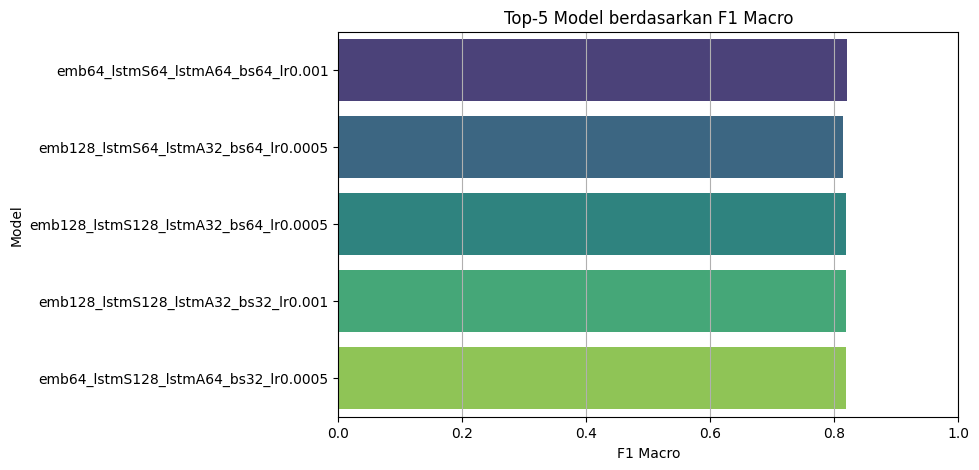

In [ ]:
# ==========================================
# 🔹 17. Grafik Top-5 Model berdasarkan F1 Macro
# ==========================================

# Urutkan berdasarkan F1 Macro
top5_models = results_df.sort_values("f1_macro", ascending=False).head(5)

plt.figure(figsize=(8,5))
sns.barplot(
    x="f1_macro",
    y=top5_models.index,
    data=top5_models,
    palette="viridis",
    orient="h"
)

# Label model biar lebih jelas
plt.yticks(ticks=range(len(top5_models)), labels=[
    f"emb{row['embedding_dim']}_lstmS{row['lstm_units_sentence']}_lstmA{row['lstm_units_aspect']}_bs{row['batch_size']}_lr{row['learning_rate']}"
    for _, row in top5_models.iterrows()
])

plt.title("Top-5 Model berdasarkan F1 Macro")
plt.xlabel("F1 Macro")
plt.ylabel("Model")
plt.xlim(0, 1.0)  # skala biar konsisten
plt.grid(True, axis="x")
plt.show()


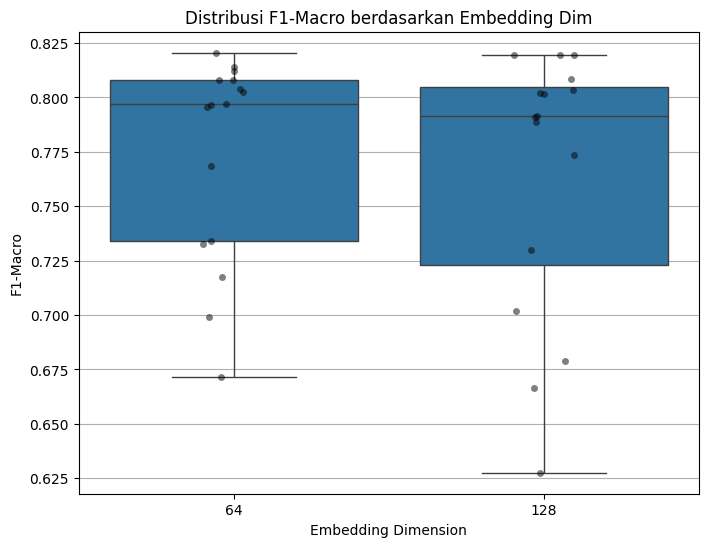

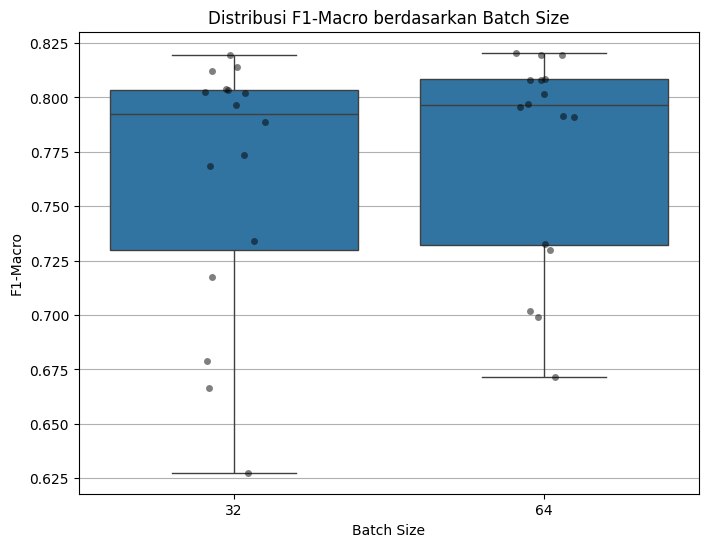

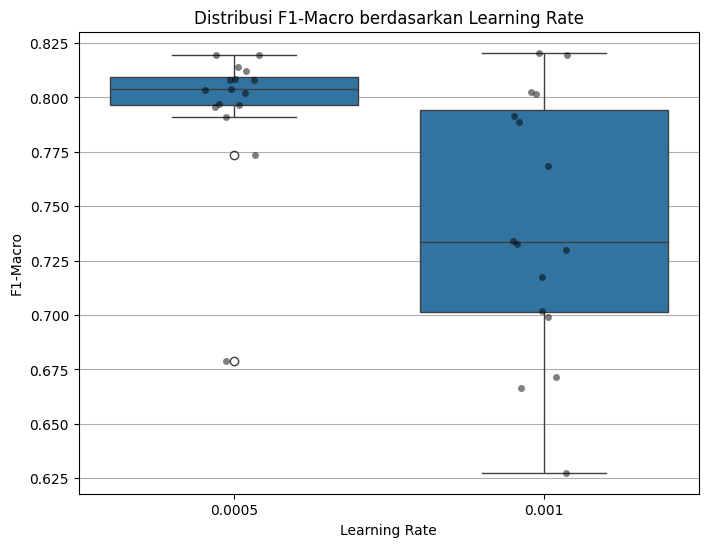

/tmp/ipython-input-2157467680.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metrics_df, x="metric", y="score", palette="Set2")


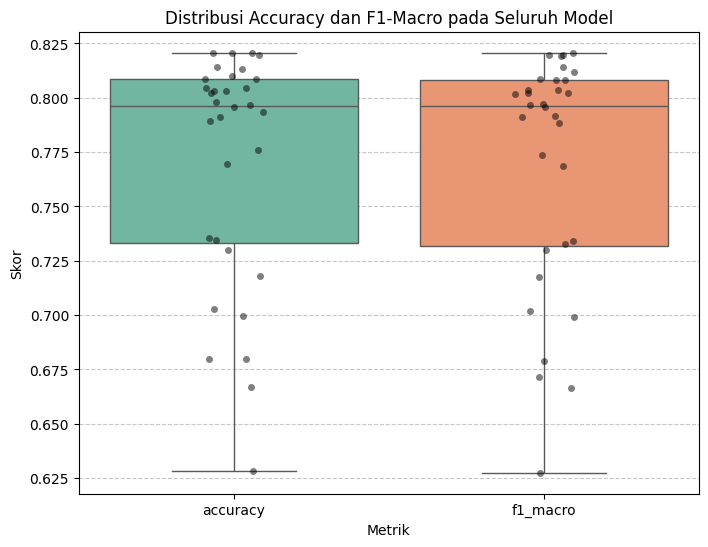

In [ ]:
# ==========================================
# 🔹 18. Boxplot F1-Macro per Parameter
# ==========================================
# F1-macro dengan embedding dim
plt.figure(figsize=(8,6))
sns.boxplot(data=results_df, x="embedding_dim", y="f1_macro")
sns.stripplot(data=results_df, x="embedding_dim", y="f1_macro",
              color="black", alpha=0.5, jitter=True)  # biar titik individual juga kelihatan

plt.title("Distribusi F1-Macro berdasarkan Embedding Dim")
plt.xlabel("Embedding Dimension")
plt.ylabel("F1-Macro")
plt.grid(axis="y")
plt.show()

# F1-macro dengan batch_size
plt.figure(figsize=(8,6))
sns.boxplot(data=results_df, x="batch_size", y="f1_macro")
sns.stripplot(data=results_df, x="batch_size", y="f1_macro",
              color="black", alpha=0.5, jitter=True)

plt.title("Distribusi F1-Macro berdasarkan Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("F1-Macro")
plt.grid(axis="y")
plt.show()

# F1-macro dengan learning rate
plt.figure(figsize=(8,6))
sns.boxplot(data=results_df, x="learning_rate", y="f1_macro")
sns.stripplot(data=results_df, x="learning_rate", y="f1_macro",
              color="black", alpha=0.5, jitter=True)

plt.title("Distribusi F1-Macro berdasarkan Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("F1-Macro")
plt.grid(axis="y")
plt.show()

# F1-macro dengan accuracy
metrics_df = results_df.melt(
    value_vars=["accuracy", "f1_macro"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(8,6))
sns.boxplot(data=metrics_df, x="metric", y="score", palette="Set2")
sns.stripplot(data=metrics_df, x="metric", y="score",
              color="black", alpha=0.5, jitter=True)

plt.title("Distribusi Accuracy dan F1-Macro pada Seluruh Model")
plt.xlabel("Metrik")
plt.ylabel("Skor")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# **Confusion Matrix dan Classification Report**

Hanya untuk model terbaik

In [ ]:
# ==========================================
# 🔹 15. Classification Report
# ==========================================
# Prediksi dengan best model
y_pred = (best_overall_model.predict([X_test_sent, X_test_asp]) > 0.5).astype(int).reshape(-1)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.82      0.81       437
    Positive       0.84      0.82      0.83       478

    accuracy                           0.82       915
   macro avg       0.82      0.82      0.82       915
weighted avg       0.82      0.82      0.82       915



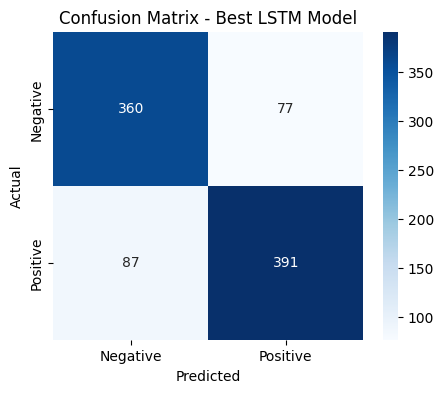

In [ ]:
# ==========================================
# 🔹 16. Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best LSTM Model")
plt.show()